In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv('heart.csv')

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 918
Number of columns: 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (918, 12)


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
print(df['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


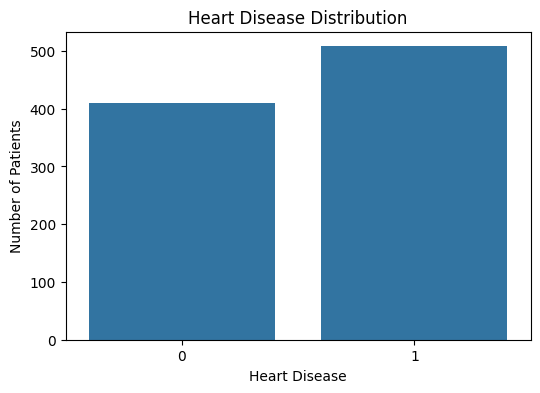

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='HeartDisease', data=df)

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')

plt.show()

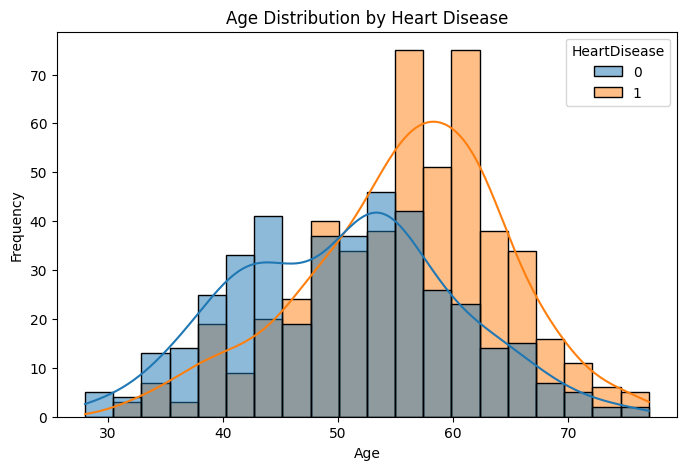

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Age', hue='HeartDisease',
             kde=True, bins=20)

plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

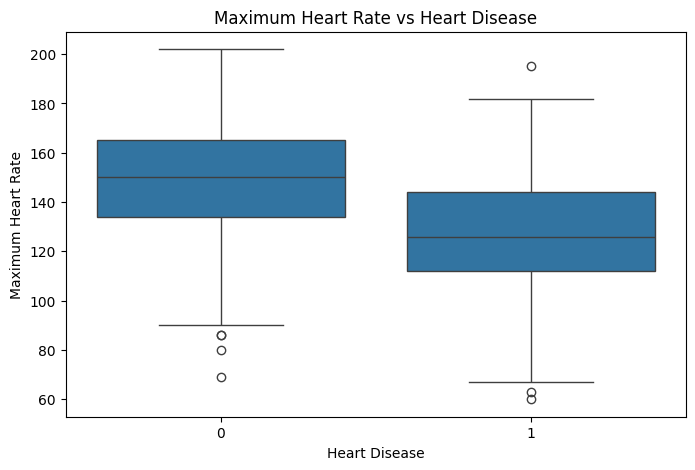

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='HeartDisease', y='MaxHR', data=df)

plt.title('Maximum Heart Rate vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Maximum Heart Rate')

plt.show()

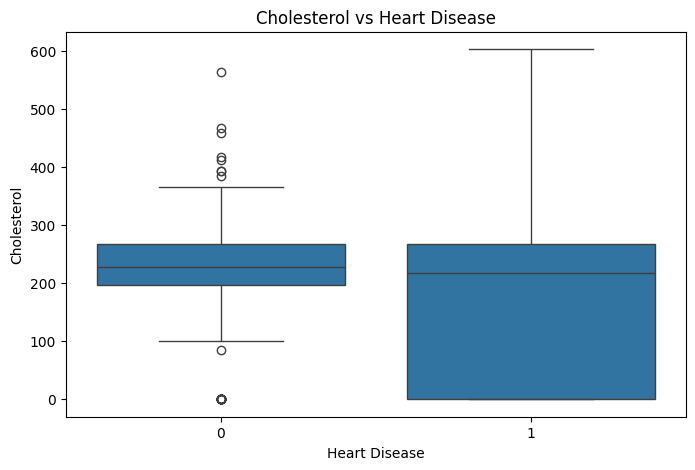

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)

plt.title('Cholesterol vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')

plt.show()

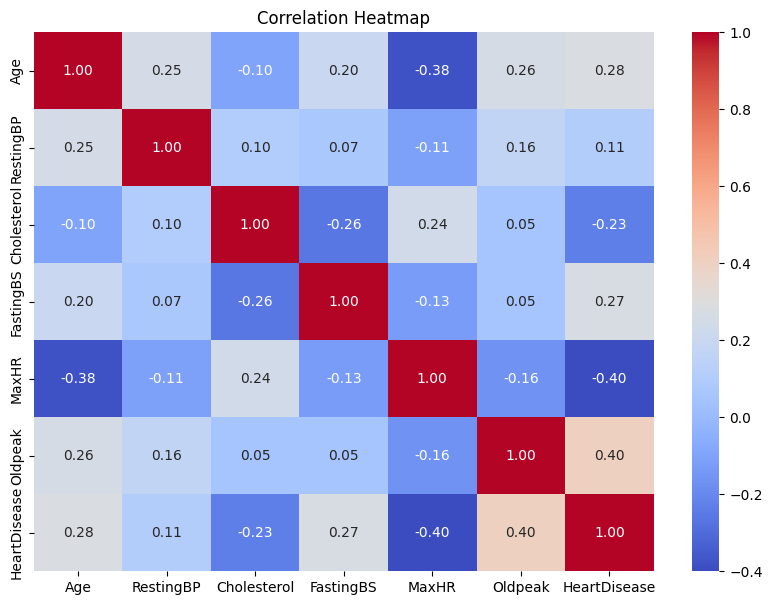

In [ ]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
X = df.drop('HeartDisease', axis=1)

y = df['HeartDisease']

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (918, 11)
Target shape: (918,)


In [ ]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Numerical Features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 734
Testing samples: 184


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ]
)

In [ ]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = pipeline.predict(X_test)

print(y_pred)

[1 0 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1
 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1
 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1
 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1
 1 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 0 1 1 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8858695652173914
Accuracy (%): 88.58695652173914


In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8715596330275229
Recall: 0.9313725490196079
F1 Score: 0.9004739336492891


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[68 14]
 [ 7 95]]


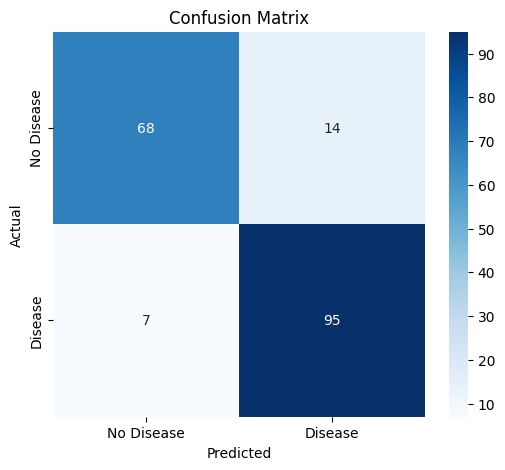

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
y_probability = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9299378287900525


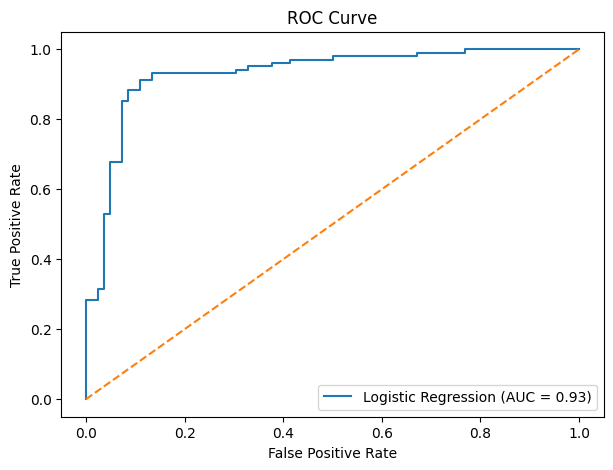

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [ ]:
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = pipeline.named_steps[
    'classifier'
].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Absolute_Coefficient'] = \
    coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
19,cat__ST_Slope_Up,-1.325803,1.325803
8,cat__ChestPainType_ASY,1.193180,1.193180
18,cat__ST_Slope_Flat,1.089095,1.089095
10,cat__ChestPainType_NAP,-0.642273,0.642273
6,cat__Sex_F,-0.635529,0.635529
7,cat__Sex_M,0.531010,0.531010
15,cat__ExerciseAngina_N,-0.502676,0.502676
2,num__Cholesterol,-0.492059,0.492059
9,cat__ChestPainType_ATA,-0.439494,0.439494
3,num__FastingBS,0.430936,0.430936


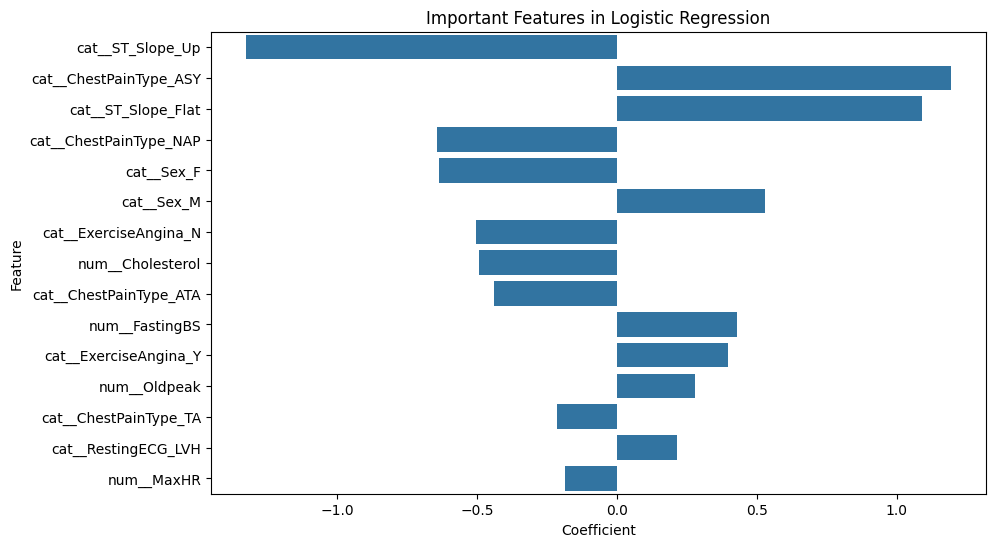

In [ ]:
top_features = coef_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Important Features in Logistic Regression')

plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

In [ ]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

results

,Metric,Score
0,Accuracy,0.885870
1,Precision,0.871560
2,Recall,0.931373
3,F1 Score,0.900474
4,ROC-AUC,0.929938


In [ ]:
results['Percentage'] = results['Score'] * 100

results

,Metric,Score,Percentage
0,Accuracy,0.885870,88.586957
1,Precision,0.871560,87.155963
2,Recall,0.931373,93.137255
3,F1 Score,0.900474,90.047393
4,ROC-AUC,0.929938,92.993783


In [ ]:
new_patient = pd.DataFrame({
    'Age': [50],
    'Sex': ['M'],
    'ChestPainType': ['ATA'],
    'RestingBP': [140],
    'Cholesterol': [250],
    'FastingBS': [0],
    'RestingECG': ['Normal'],
    'MaxHR': [150],
    'ExerciseAngina': ['N'],
    'Oldpeak': [1.0],
    'ST_Slope': ['Up']
})

prediction = pipeline.predict(new_patient)

probability = pipeline.predict_proba(new_patient)[0][1]

print("Predicted class:", prediction[0])
print("Predicted probability for class 1:", probability)

Predicted class: 0
Predicted probability for class 1: 0.07350633739649524


In [ ]:
if prediction[0] == 1:
    print("Model classification: Heart Disease")
else:
    print("Model classification: No Heart Disease")

Model classification: No Heart Disease


In [ ]:
import joblib

joblib.dump(
    pipeline,
    'heart_disease_logistic_regression.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download(
    'heart_disease_logistic_regression.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results.to_csv(
    'model_evaluation_results.csv',
    index=False
)

In [ ]:
print("===== HEART DISEASE PREDICTION RESULTS =====")

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC   : {auc_score:.4f}")

===== HEART DISEASE PREDICTION RESULTS =====
Accuracy  : 0.8859 (88.59%)
Precision : 0.8716 (87.16%)
Recall    : 0.9314 (93.14%)
F1 Score  : 0.9005 (90.05%)
ROC-AUC   : 0.9299


In [ ]:
print("===== SAMPLE PATIENT PREDICTION =====")

if prediction[0] == 1:
    print("Predicted Class: Heart Disease")
else:
    print("Predicted Class: No Heart Disease")

print(f"Probability of class 1: {probability:.2%}")

===== SAMPLE PATIENT PREDICTION =====
Predicted Class: No Heart Disease
Probability of class 1: 7.35%


In [ ]:
print("===== SAMPLE PATIENT PREDICTION =====")

if prediction[0] == 0:
    print("Predicted Class: Heart Disease Detected")
else:
    print("Predicted Class: No Heart Disease")

print(f"Probability of class 1: {probability:.2%}")

===== SAMPLE PATIENT PREDICTION =====
Predicted Class: Heart Disease Detected
Probability of class 1: 7.35%
